# <span style="color:#0097b2">0. Data</span>
[Back to TOC](#toc)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Libraries Importation</h3>

In [ ]:
from notebooks.utils.functions import *

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Data Importation</h3>

In [12]:
people = pd.read_csv("../data/cleaned_data/clustering_data_cleaned.csv", index_col = 'Loyalty#')

In [13]:
people.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16695 entries, 100011 to 999999
Data columns (total 56 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Income                          16695 non-null  float64
 1   Customer Lifetime Value         16695 non-null  float64
 2   EnrollmentType                  16695 non-null  int64  
 3   rejoined_program                16695 non-null  int64  
 4   Days_in_prog                    16695 non-null  float64
 5   Cancelled_program               16695 non-null  int64  
 6   Enrollment_year                 16695 non-null  int64  
 7   Enrollment_month                16695 non-null  int64  
 8   Location_cluster                16695 non-null  int64  
 9   TotalFlights                    16695 non-null  float64
 10  TotalDistance                   16695 non-null  float64
 11  TotalPointsAccumulated          16695 non-null  float64
 12  TotalPointsRedeemed            

In [14]:
people

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,Location_cluster,TotalFlights,...,Loyalty_Nova,Loyalty_Star,Education_Bachelor,Education_College,Education_Doctor,Education_High School or Below,Education_Master,Marital_Divorced,Marital_Married,Marital_Single
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,1,0.0,...,0,1,1,0,0,0,0,0,1,0
100012,34148.0,5780.18,0,0,0.0,0,2019,2,4,0.0,...,0,1,1,0,0,0,0,0,0,1
100013,34148.0,5780.18,0,0,0.0,0,2017,9,5,0.0,...,0,1,1,0,0,0,0,0,1,0
100014,34148.0,5780.18,0,0,0.0,0,2020,11,3,0.0,...,0,1,1,0,0,0,0,0,1,0
100015,34148.0,5780.18,0,0,0.0,0,2020,4,4,0.0,...,0,1,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,4,0.0,...,0,1,0,1,0,0,0,0,1,0
999996,34148.0,5780.18,0,0,0.0,0,2018,9,1,0.0,...,0,1,1,0,0,0,0,0,0,1
999997,34148.0,5780.18,0,0,0.0,0,2020,1,3,0.0,...,0,1,0,1,0,0,0,0,1,0


In [16]:
people1 = people.copy()

In [17]:
for column in people1.columns:
    if column.startswith('Total_Spend_Month_'):
        people1[column] = np.sqrt(people1[column])

In [18]:
people_st_scl = StandardScaler().fit_transform(people1)
people_mm_scl = MinMaxScaler().fit_transform(people1)
people_rb_scl = RobustScaler().fit_transform(people1)

# <span style="color:#0097b2">1. Modelling</span>
[Back to TOC](#toc)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Standard Scaling</h3>

### K-Means

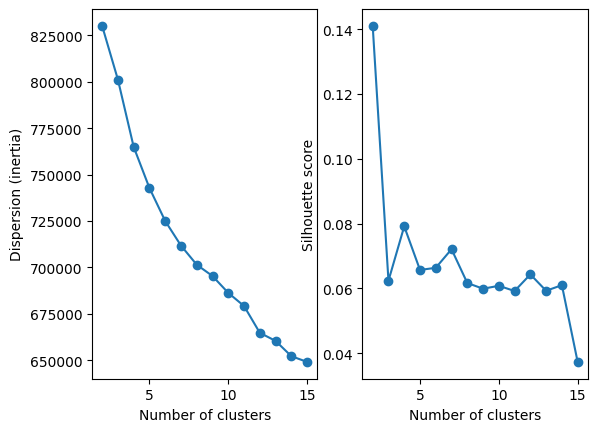

In [19]:
plot_inertia_and_silhouette(people_st_scl)

In [42]:
kmeans_st_scl = KMeans(n_clusters=10, random_state=42).fit(people_st_scl)
people['st_scaled_km_cluster10'] = kmeans_st_scl.predict(people_st_scl)

In [43]:
groupby_mean(people, 'st_scaled_km_cluster10')

st_scaled_km_cluster10,0,1,2,3,4,5,6,7,8,9
Income,37078.281416,38020.955645,53317.580946,40860.657178,42415.635629,996.879984,37605.158004,40146.849158,39292.530928,40328.129404
Customer Lifetime Value,8070.975221,8325.356230,8110.227746,7822.222725,7952.641587,7378.107818,7985.802807,8164.028254,8137.207887,8170.022683
EnrollmentType,0.010619,0.018145,0.036772,0.263522,0.036580,0.038224,0.000000,0.045942,0.087629,0.037263
rejoined_program,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
Days_in_prog,514.311504,589.860887,1440.729943,324.517690,1443.397150,1347.824085,88.729730,1409.809342,163.335052,1350.527100
Cancelled_program,0.892035,0.627688,0.022684,0.120781,0.025178,0.032059,0.012474,0.031394,0.000000,0.024390
Enrollment_year,2018.902655,2017.743280,2017.548233,2020.576657,2017.514489,2017.776819,2020.981289,2017.616386,2020.994845,2017.774390
Enrollment_month,7.621239,7.307796,6.423114,5.989833,6.718765,6.576243,9.619543,6.524502,7.185567,6.630759
Location_cluster,2.376991,2.465726,2.463706,2.509557,2.417102,2.424168,2.380457,2.420368,2.128866,2.403117
TotalFlights,58.180177,0.000000,190.828176,65.163359,200.066033,184.559268,14.230353,198.514395,24.294330,183.745799


### Hierarchichal - Ward

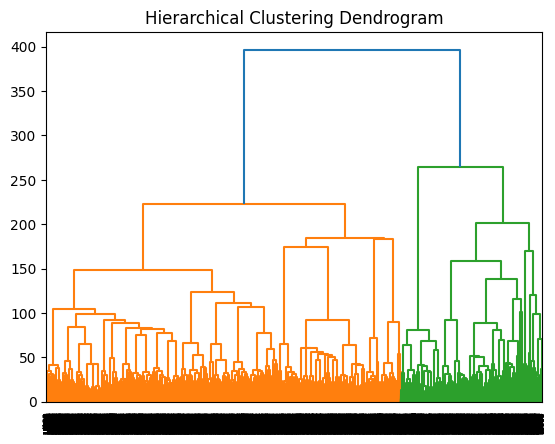

In [22]:
plot_dendrogram(people_st_scl, 'ward')

In [ ]:
people['st_scaled_ward_cluster10'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 10
    ).fit_predict(people_st_scl)

In [ ]:
groupby_mean(people, 'st_scaled_ward_cluster10')

st_scaled_ward_cluster7,0,1,2,3,4,5,6
Income,5348.327328,38500.990491,20058.625723,50148.640904,43755.450823,39463.393324,20751.137014
Customer Lifetime Value,7255.997835,7868.192647,7682.239682,8297.774799,7781.161057,8318.104949,7472.455992
EnrollmentType,0.021074,0.028526,0.059249,0.006771,0.334552,0.017417,0.049080
rejoined_program,0.000000,0.307448,0.000000,0.000000,0.000000,0.000000,0.000000
Days_in_prog,1273.510537,112.025357,1188.670520,1412.316045,428.980256,588.145138,1119.378323
Cancelled_program,0.025493,0.007924,0.118497,0.023122,0.285192,0.625544,0.120654
Enrollment_year,2017.978586,2020.984152,2017.956647,2017.606796,2020.095795,2017.752540,2018.173824
Enrollment_month,6.700544,8.887480,6.828035,6.636561,5.826325,7.266328,6.822086
Location_cluster,2.422162,2.269414,2.433526,2.432805,2.504205,2.460087,2.511247
TotalFlights,172.752515,17.769889,153.153035,188.720580,83.610347,0.000000,149.455010


## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">MinMax Scaling</h3>

### K-Means

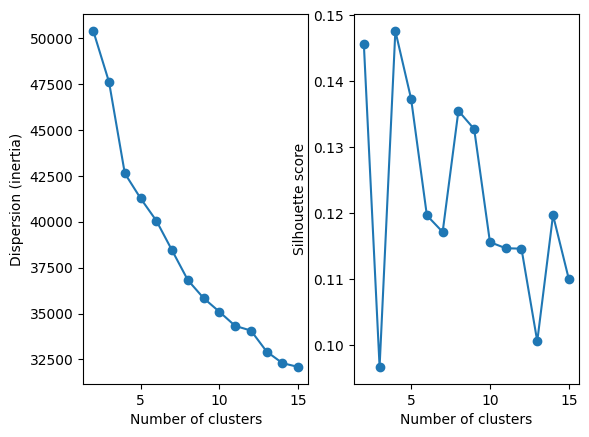

In [25]:
plot_inertia_and_silhouette(people_mm_scl)

In [26]:
kmeans_mm_scl = KMeans(n_clusters=7, random_state=42).fit(people_mm_scl)
people['mm_scaled_km_cluster7'] = kmeans_mm_scl.predict(people_mm_scl)

In [27]:
groupby_mean(people, 'mm_scaled_km_cluster7')

mm_scaled_km_cluster7,0,1,2,3,4,5,6
Income,19664.094741,50593.450783,51636.573103,17401.924538,53356.165282,189.711111,46130.303249
Customer Lifetime Value,6430.036465,6913.582847,7992.618607,8638.820350,10569.347225,7730.802444,8285.715952
EnrollmentType,0.061352,0.065716,0.067931,0.074463,0.068790,0.074306,0.069043
rejoined_program,0.009182,0.012864,0.009655,0.014993,0.011542,0.009028,0.013538
Days_in_prog,1107.370200,1100.954698,1079.640000,1080.634183,1100.134349,1080.602778,1084.878159
Cancelled_program,0.116444,0.116051,0.125172,0.128436,0.131117,0.132639,0.115072
Enrollment_year,2018.232053,2018.233781,2018.279655,2018.278361,2018.209141,2018.243750,2018.281588
Enrollment_month,6.589733,6.696868,6.697586,6.656672,6.660665,6.654861,6.674639
Location_cluster,2.429048,2.439877,2.481379,2.476762,2.423361,2.397222,2.416516
TotalFlights,144.100501,144.989374,143.128207,145.975962,144.355217,142.110694,142.719224


### Hierarchichal - Ward

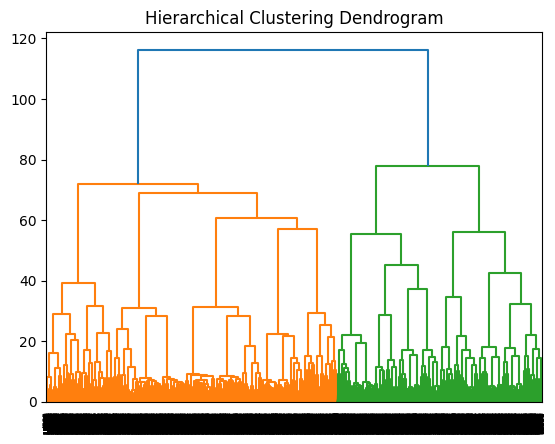

In [28]:
plot_dendrogram(people_mm_scl, 'ward')

In [29]:
people['mm_scaled_ward_cluster7'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 7
    ).fit_predict(people_mm_scl)

In [30]:
groupby_mean(people, 'mm_scaled_ward_cluster7')

mm_scaled_ward_cluster7,0,1,2,3,4,5,6
Income,43155.466121,9557.405046,15135.066204,39761.072760,56545.478856,56328.110248,57486.599444
Customer Lifetime Value,7765.028513,7782.513577,7912.511180,8132.342413,7938.460601,7057.757838,10396.306147
EnrollmentType,0.067757,0.072598,0.067361,0.034605,0.067993,0.076087,0.075800
rejoined_program,0.012266,0.007968,0.011564,0.014197,0.010365,0.013975,0.011822
Days_in_prog,1093.649825,1176.592740,1104.417462,639.554570,1084.483831,1170.129270,1149.555633
Cancelled_program,0.109813,0.034086,0.118242,0.664596,0.126866,0.006988,0.075800
Enrollment_year,2018.280666,2018.223108,2018.245736,2018.060337,2018.276534,2018.286491,2018.278164
Enrollment_month,6.632301,6.693227,6.660306,7.171251,6.596186,6.588121,6.572323
Location_cluster,2.432827,2.403276,2.433073,2.471162,2.473881,2.460404,2.425591
TotalFlights,144.264982,162.549712,147.771813,21.995209,148.602405,163.041343,159.233102


## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Robust Scaling</h3>

### K-Means

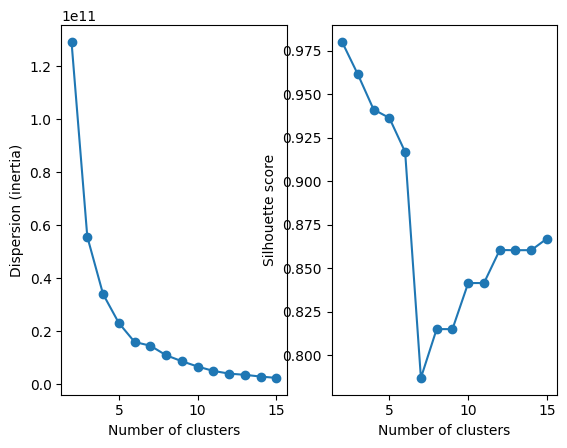

In [31]:
plot_inertia_and_silhouette(people_rb_scl)

In [32]:
kmeans_rb_scl = KMeans(n_clusters=7, random_state=42).fit(people_rb_scl)
people['rb_scaled_km_cluster7'] = kmeans_rb_scl.predict(people_rb_scl)

In [33]:
groupby_mean(people, 'rb_scaled_km_cluster7')

rb_scaled_km_cluster7,0,1,2,3,4,5,6
Income,37716.953768,52294.500000,36174.671642,36798.615385,38042.278281,36981.969697,41718.456954
Customer Lifetime Value,7805.504747,17897.248462,11412.979552,11830.339231,10948.827104,10775.058182,11939.721854
EnrollmentType,0.069849,0.000000,0.014925,0.000000,0.042986,0.000000,0.013245
rejoined_program,0.007580,0.115385,0.059701,0.076923,0.110860,0.060606,0.092715
Days_in_prog,1136.898641,66.923077,62.641791,75.230769,128.809955,62.757576,82.079470
Cancelled_program,0.124601,0.038462,0.059701,0.000000,0.099548,0.030303,0.033113
Enrollment_year,2018.129111,2020.923077,2020.970149,2021.000000,2020.864253,2020.939394,2020.980132
Enrollment_month,6.560233,10.230769,9.910448,10.000000,8.375566,10.303030,9.655629
Location_cluster,2.444841,2.538462,2.462687,2.307692,2.309955,2.333333,2.430464
TotalFlights,149.554301,4.880769,16.382090,2.076923,29.085520,14.233333,17.104636


### Hierarchichal - Ward

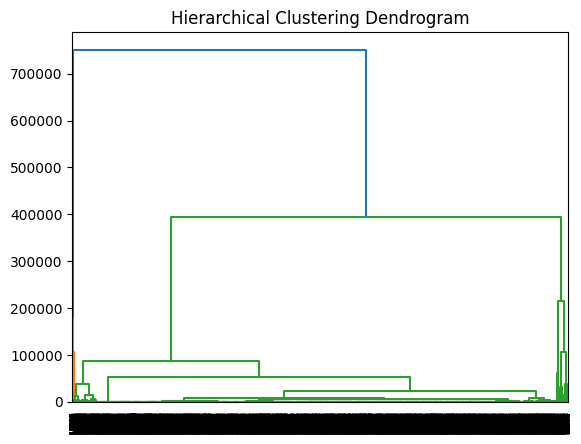

In [34]:
plot_dendrogram(people_rb_scl, 'ward')

In [35]:
people['rb_scaled_ward_cluster7'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 7
    ).fit_predict(people_rb_scl)

In [36]:
groupby_mean(people, 'rb_scaled_ward_cluster7')

rb_scaled_ward_cluster7,0,1,2,3,4,5,6
Income,37716.155975,35672.400000,50458.736842,40376.858407,35702.181818,40006.403846,44550.550000
Customer Lifetime Value,7861.229918,11163.191538,20214.297368,11752.112478,12490.637273,11313.018750,11850.565500
EnrollmentType,0.069561,0.015385,0.000000,0.008850,0.000000,0.019231,0.000000
rejoined_program,0.009902,0.061538,0.210526,0.106195,0.000000,0.057692,0.050000
Days_in_prog,1118.764008,63.738462,64.684211,75.646018,71.090909,99.105769,66.350000
Cancelled_program,0.124546,0.061538,0.000000,0.026549,0.000000,0.052885,0.050000
Enrollment_year,2018.178363,2020.953846,2021.000000,2020.991150,2021.000000,2020.932692,2020.900000
Enrollment_month,6.587798,9.892308,10.210526,9.814159,10.181818,9.168269,10.250000
Location_cluster,2.441233,2.384615,2.631579,2.283186,2.090909,2.514423,2.600000
TotalFlights,147.372637,11.341538,5.315789,18.043363,2.272727,24.965385,13.425000


# <span style="color:#0097b2">1. Filtering</span>
[Back to TOC](#toc)

### <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">(1) First-Examination</h3>

#### Cluster Visualization 1

In [37]:
clusters_km = ['st_scaled_km_cluster7', 'mm_scaled_km_cluster7', 'rb_scaled_km_cluster7']

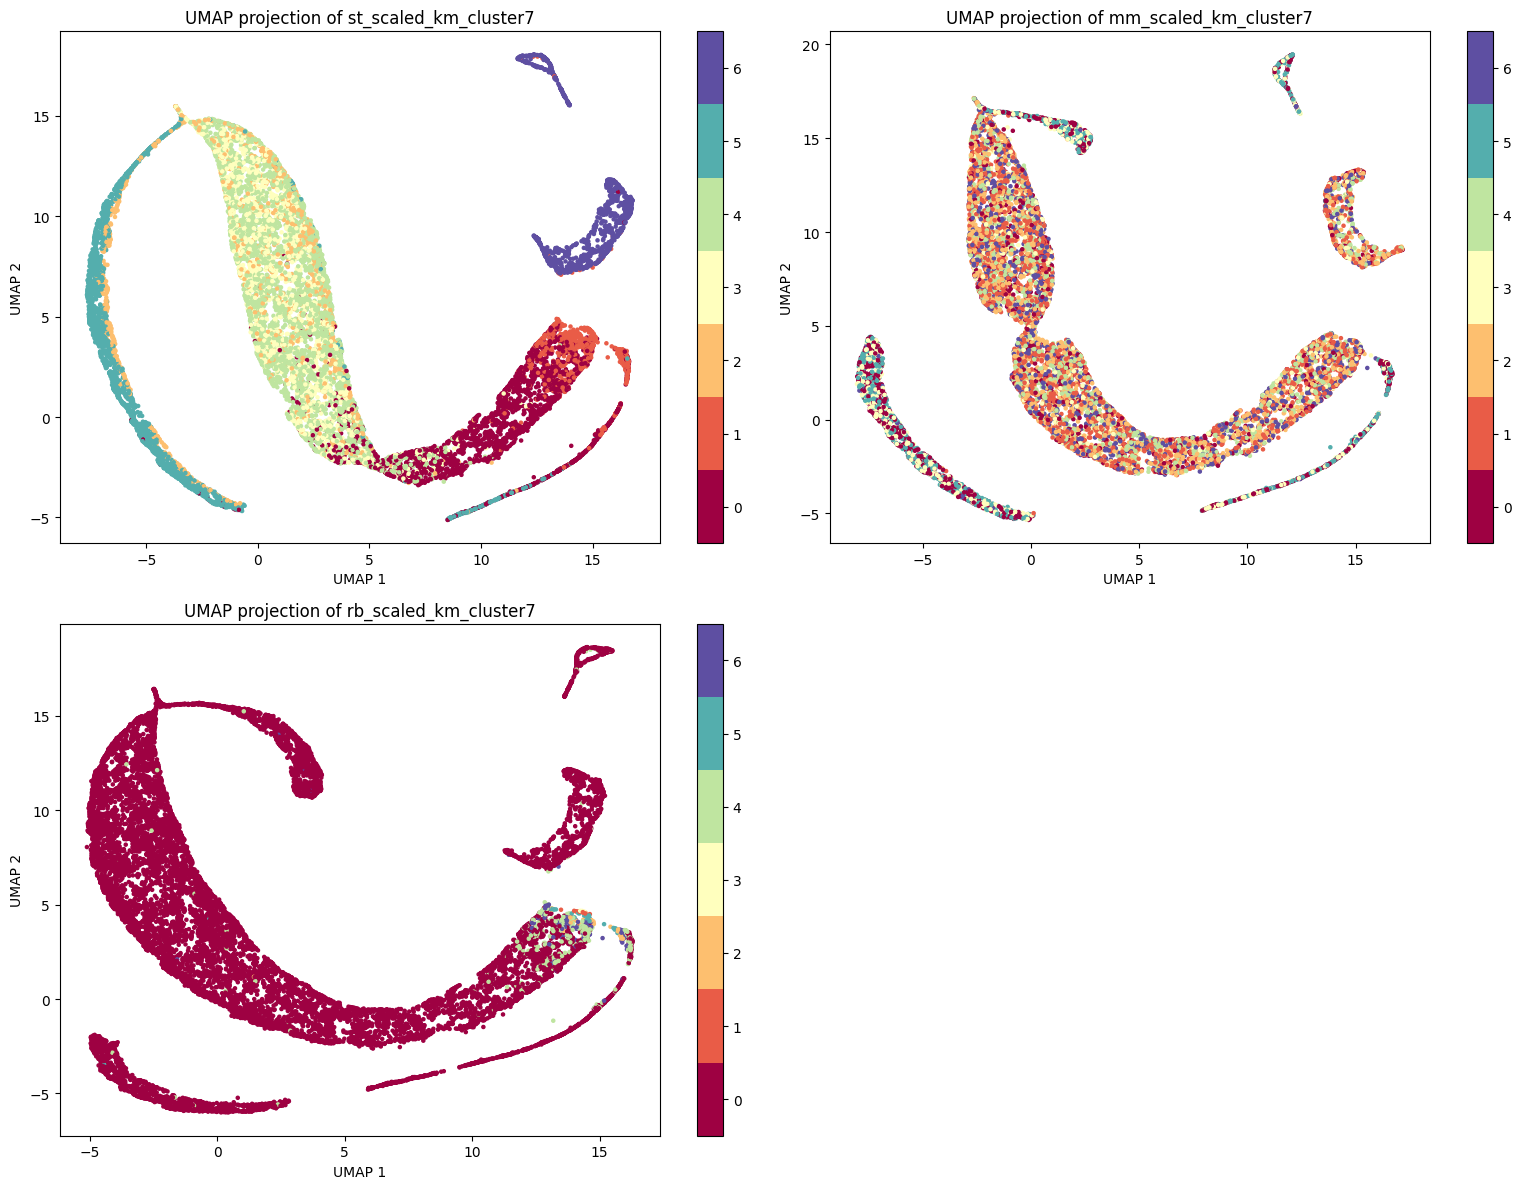

In [38]:
plot_umap_projections(people, clusters_km)

In [39]:
cluster_ward = ['st_scaled_ward_cluster7', 'mm_scaled_ward_cluster7', 'rb_scaled_ward_cluster7']

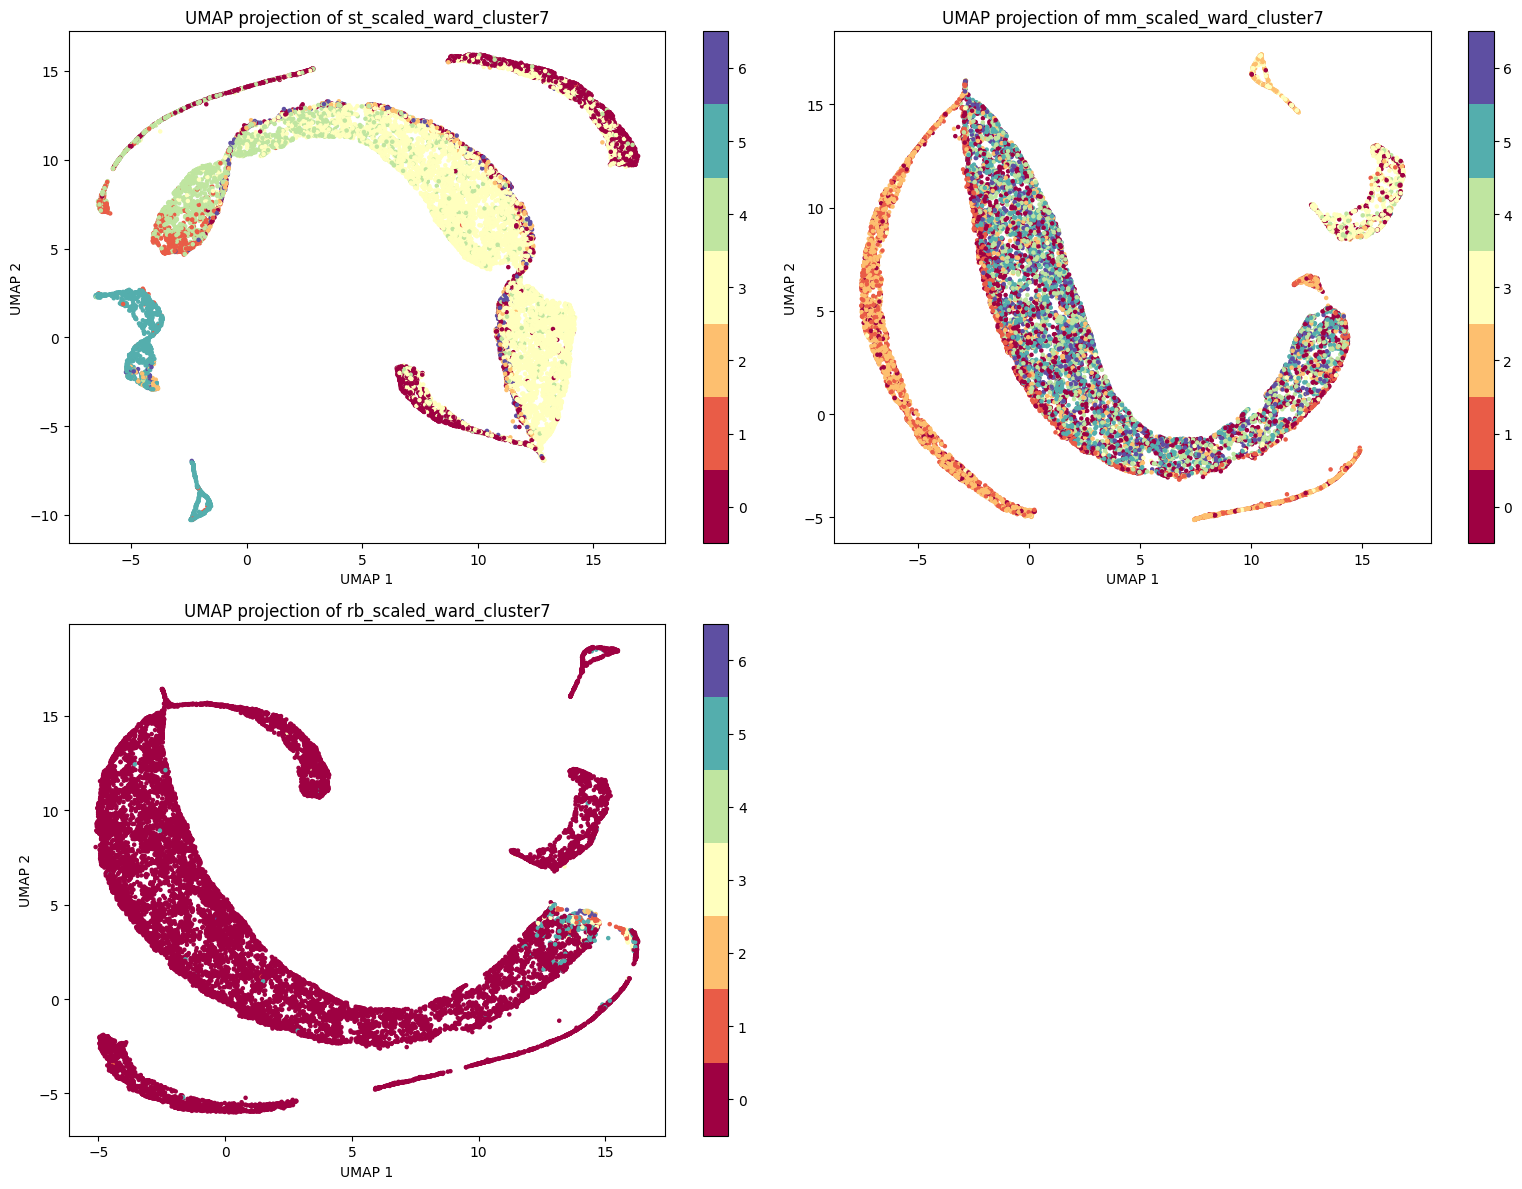

In [40]:
plot_umap_projections(people, cluster_ward)

In [41]:
groupby_mean(people, 'rb_scaled_ward_cluster7')

rb_scaled_ward_cluster7,0,1,2,3,4,5,6
Income,37716.155975,35672.400000,50458.736842,40376.858407,35702.181818,40006.403846,44550.550000
Customer Lifetime Value,7861.229918,11163.191538,20214.297368,11752.112478,12490.637273,11313.018750,11850.565500
EnrollmentType,0.069561,0.015385,0.000000,0.008850,0.000000,0.019231,0.000000
rejoined_program,0.009902,0.061538,0.210526,0.106195,0.000000,0.057692,0.050000
Days_in_prog,1118.764008,63.738462,64.684211,75.646018,71.090909,99.105769,66.350000
Cancelled_program,0.124546,0.061538,0.000000,0.026549,0.000000,0.052885,0.050000
Enrollment_year,2018.178363,2020.953846,2021.000000,2020.991150,2021.000000,2020.932692,2020.900000
Enrollment_month,6.587798,9.892308,10.210526,9.814159,10.181818,9.168269,10.250000
Location_cluster,2.441233,2.384615,2.631579,2.283186,2.090909,2.514423,2.600000
TotalFlights,147.372637,11.341538,5.315789,18.043363,2.272727,24.965385,13.425000


5(veterinaries) \ 1(Vegetarian) \ 5(Gamers) \ 7(loyals) \ 2(?) , 3(promotion) , 4(alcoholics) , 6(parents) , 8(young adults)

#### Cluster Extraction 1

In [ ]:
# Filter the DataFrame based on cluster labels
veterinaries = people[people['rb_scaled_ward_cluster7'] == 5]
vegetarians = people[people['rb_scaled_ward_cluster7'] == 4]
gamers = people[people['rb_scaled_ward_cluster7'] == 3]
loyals = people[people['rb_scaled_ward_cluster7'] == 6]

In [ ]:
# List of cluster labels to exclude
exclude_clusters = [5, 4, 3, 6]

# Filter the original dataset to exclude rows with specified cluster labels
people_filtered1 = people[~people['rb_scaled_ward_cluster7'].isin(exclude_clusters)]

In [ ]:
people_filtered1

In [ ]:
people_filtered1 = people_filtered1.iloc[:, :-6]

### <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">(2) Second-Examination</h3>

#### Re-Scaling Data 2

In [ ]:
people_filtered1

In [ ]:
people_filtered11 = people_filtered1.copy()

for column in people_filtered11.columns:
    if column.startswith('spend'):
        people_filtered11[column] = np.sqrt(people_filtered11[column])

In [ ]:
people_filtered1_st_scl = StandardScaler().fit_transform(people_filtered11)
people_filtered1_rb_scl = RobustScaler().fit_transform(people_filtered11)

#### Cluster Modelling 2

In [ ]:
plot_inertia_and_silhouette(people_filtered1_st_scl)

In [ ]:
plot_inertia_and_silhouette(people_filtered1_rb_scl)

In [ ]:
plot_dendrogram(people_filtered1_st_scl, 'ward')

In [ ]:
plot_dendrogram(people_filtered1_rb_scl, 'ward')

#### Cluster Visualization 2

In [ ]:
people_filtered1['filter1_rb_scaled_ward_cluster3'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 3
    ).fit_predict(people_filtered1_rb_scl)

people_filtered1['filter1_st_scaled_ward_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(people_filtered1_st_scl)

In [ ]:
kmeans_rb_scl = KMeans(n_clusters=5, random_state=42).fit(people_filtered1_rb_scl)
people_filtered1['filter1_rb_scaled_km_cluster5'] = kmeans_rb_scl.predict(people_filtered1_rb_scl)

kmeans_st_scl = KMeans(n_clusters=5, random_state=42).fit(people_filtered1_st_scl)
people_filtered1['filter1_st_scaled_km_cluster5'] = kmeans_st_scl.predict(people_filtered1_st_scl)

In [ ]:
cluster_filter1 = ['filter1_rb_scaled_ward_cluster3', 'filter1_st_scaled_ward_cluster2', 'filter1_rb_scaled_km_cluster5', 'filter1_st_scaled_km_cluster5']

In [ ]:
plot_umap_projections(people_filtered1, cluster_filter1)

In [ ]:
groupby_mean(people_filtered1, 'filter1_st_scaled_km_cluster5')


# CORRER OS OUTROS GROUP BY
# FAZER LABEL DOS CLUSTERS PRESENTES

In [ ]:
# 3 - alcoholics | 1 - parents | 2 - young adults technology

#### Cluster Extraction 2

In [ ]:
# Filter the DataFrame based on cluster labels
alcoholics = people_filtered1[people_filtered1['filter1_st_scaled_km_cluster5'] == 3]

In [ ]:
# List of cluster labels to exclude
exclude_clusters = [3]

# Filter the original dataset to exclude rows with specified cluster labels
people_filter2 = people_filtered1[~people_filtered1['filter1_st_scaled_km_cluster5'].isin(exclude_clusters)]

In [ ]:
people_filter2 = people_filter2.iloc[:, :-4]

# <span style="color:#0097b2">1. Cluster Extraction</span>
[Back to TOC](#toc)

In [ ]:
# Define file names for CSV files
file_names = ['veterinaries.csv', 'vegetarians.csv', 'gamers.csv', 'loyals.csv', 'alcoholics.csv', 'families.csv', 'young_adults.csv', 'karens.csv', 'promo_hunters.csv']

# Define dataframes and filenames
datasets = [veterinaries, vegetarians, gamers, loyals, alcoholics, families, young_adults, karens, promo_hunters]

# Save each subset as a CSV file
for df, file_name in zip(datasets, file_names):
    df.to_csv(file_name)